In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Stile grafici
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('../data/heart_cleaned.csv')

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dimensioni Training set: {X_train.shape}")
print(f"Dimensioni Test set: {X_test.shape}")
print("\nDistribuzione classi nel Test set:")
print(y_test.value_counts(normalize=True))

Dimensioni Training set: (241, 13)
Dimensioni Test set: (61, 13)

Distribuzione classi nel Test set:
target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


In [4]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

X_train_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
128,1.421944,0,2,-0.973041,5.882908,0,0,0.408240,0,0.527263,1,0,3
158,-0.465841,1,0,0.756507,-0.885696,0,0,-1.104705,1,-0.083233,1,0,3
265,0.422528,1,0,-0.197726,-0.588175,0,0,-0.882213,1,1.050546,1,3,3
262,1.644036,1,2,0.517949,0.118437,0,0,-0.214737,0,0.876119,1,3,3
136,-1.021072,0,1,-1.151959,-1.629499,0,1,-0.570724,0,-0.868157,1,0,2


In [5]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    #addestramento
    model.fit(X_train_scaled, y_train)

    #predizione
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensibilità)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
df_results = pd.DataFrame(results).round(3)
df_results

,Model,Accuracy,Precision,Recall (Sensibilità),F1-Score,ROC-AUC
0,Logistic Regression,0.803,0.800,0.848,0.824,0.870
1,Random Forest,0.754,0.765,0.788,0.776,0.858
2,KNN,0.787,0.812,0.788,0.800,0.812


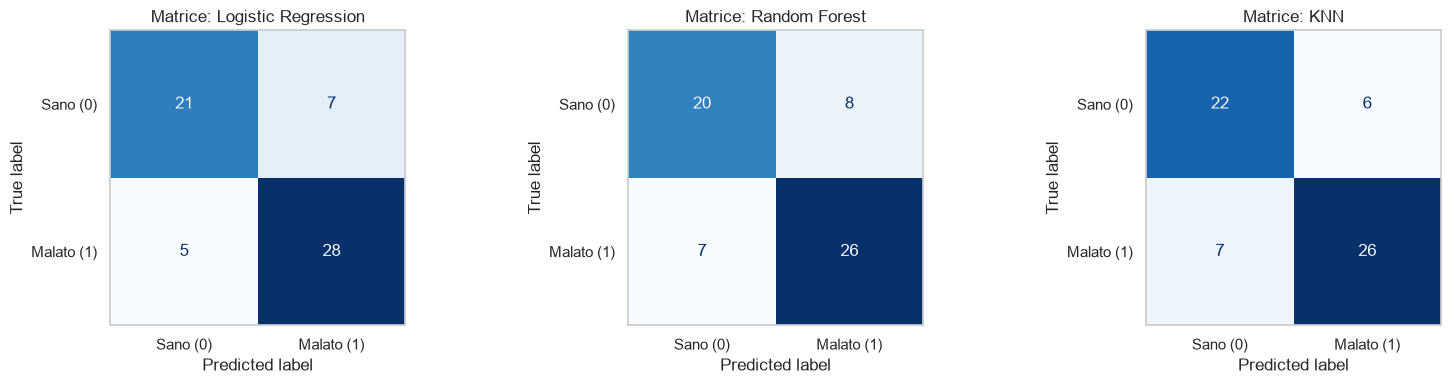

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano (0)", "Malato (1)"])
    disp.plot(ax=axes[idx], colorbar=False, cmap="Blues")
    axes[idx].set_title(f"Matrice: {name}")
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

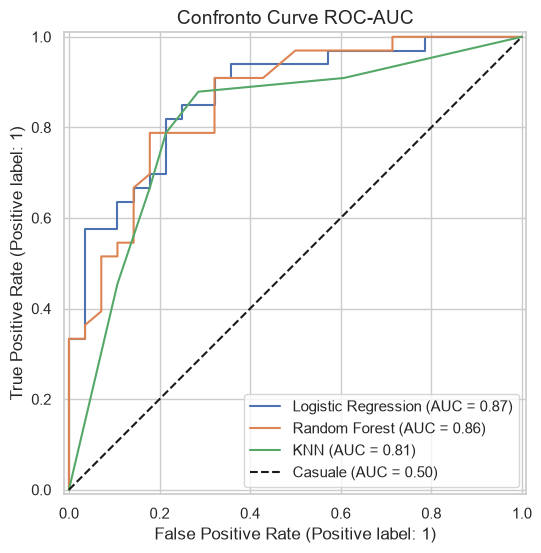

In [7]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)

plt.plot([0, 1], [0, 1], "k--", label="Casuale (AUC = 0.50)")
plt.title("Confronto Curve ROC-AUC", fontsize=14)
plt.legend(loc="lower right")
plt.show()